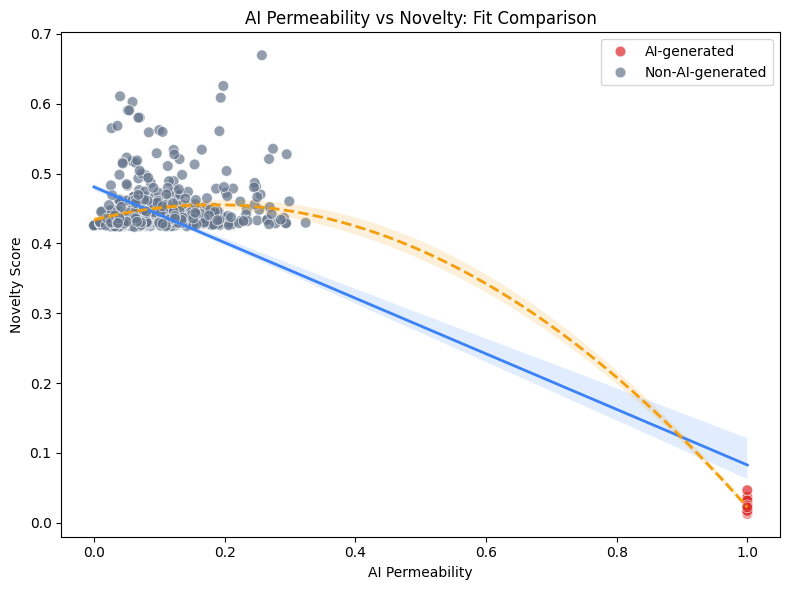

Linear Fit R²: 0.7129
Quadratic Fit R²: 0.8606

Work Type Distribution:
work_type
Non-AI-generated    575
AI-generated         20
Name: count, dtype: int64


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 读取数据
df = pd.read_csv("merged_novelty_usefulness_results.csv")

# 2. 仅按AI permeability=1区分作品类型（核心调整）
# AI permeability=1 → AI-generated；其他 → Non-AI-generated
df["work_type"] = df["ai_permeability"].apply(lambda x: "AI-generated" if x == 1 else "Non-AI-generated")

# 3. 准备二次项（用于非线性拟合）
df["ai_perm_sq"] = df["ai_permeability"] ** 2

# 4. 生成拟合图
plt.figure(figsize=(8, 6))

# 散点图（按作品类型分色）
sns.scatterplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    hue="work_type",
    palette={"Non-AI-generated": "#64748B", "AI-generated": "#DC2626"},  # 灰色=非AI生成，红色=AI生成
    alpha=0.7,
    s=60  # 散点大小，更清晰
)

# 线性拟合（蓝色实线）
sns.regplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    order=1,
    color="#3B82F6",
    scatter=False,
    line_kws={"linewidth": 2, "label": "Linear Fit"}
)

# 二次拟合（红色虚线，检验非线性）
sns.regplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    order=2,
    color="#F59E0B",  # 橙色虚线，区分线性拟合
    scatter=False,
    line_kws={"linewidth": 2, "linestyle": "--", "label": "Quadratic Fit"}
)

# 全英文标签（避免乱码）
plt.title("AI Permeability vs Novelty: Fit Comparison")
plt.xlabel("AI Permeability")
plt.ylabel("Novelty Score")
plt.legend(loc="best")  # 自动放在最优位置，避免遮挡

plt.tight_layout()
plt.show()

# 计算拟合优度R²（用于论文量化分析）
# 线性拟合R²
X_linear = df[["ai_permeability"]]
y = df["Novelty"]
model_linear = LinearRegression().fit(X_linear, y)
r2_linear = r2_score(y, model_linear.predict(X_linear))

# 二次拟合R²
X_quad = df[["ai_permeability", "ai_perm_sq"]]
model_quad = LinearRegression().fit(X_quad, y)
r2_quad = r2_score(y, model_quad.predict(X_quad))

# 打印结果（论文可直接引用）
print(f"Linear Fit R²: {r2_linear:.4f}")
print(f"Quadratic Fit R²: {r2_quad:.4f}")
print("\nWork Type Distribution:")
print(df["work_type"].value_counts())

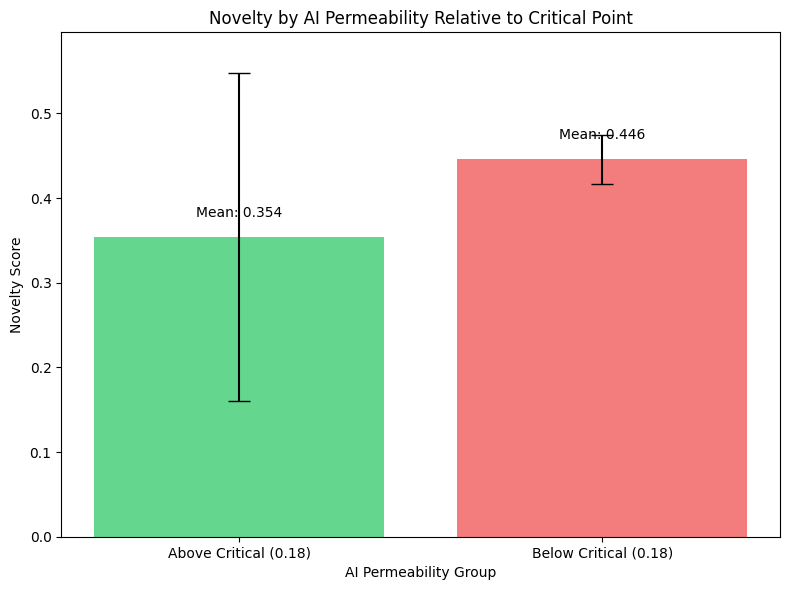

Critical AI Permeability (Max Novelty): 0.1828

Novelty Statistics by Group:
              perm_group   mean    std
0  Above Critical (0.18)  0.354  0.193
1  Below Critical (0.18)  0.446  0.029


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. 读取数据+拟合二次模型
df = pd.read_csv("merged_novelty_usefulness_results.csv")
df["ai_perm_sq"] = df["ai_permeability"] ** 2

# 二次回归模型
X = df[["ai_permeability", "ai_perm_sq"]]
y = df["Novelty"]
model = LinearRegression().fit(X, y)

# 2. 计算倒U型顶点（创新性最高的AI渗透率=临界点）
# 二次函数 y = a*x² + b*x + c，顶点x = -b/(2a)
a = model.coef_[1]  # 二次项系数
b = model.coef_[0]  # 一次项系数
critical_perm = -b / (2 * a)  # 临界点

# 3. 按临界点分组，计算创新性均值
df["perm_group"] = df["ai_permeability"].apply(
    lambda x: f"Below Critical ({round(critical_perm,2)})" if x < critical_perm 
    else f"Above Critical ({round(critical_perm,2)})"
)
novelty_by_group = df.groupby("perm_group")["Novelty"].agg(["mean", "std"]).reset_index()

# 4. 画分组对比图（带误差线）
plt.figure(figsize=(8, 6))
bars = plt.bar(
    x=novelty_by_group["perm_group"],
    height=novelty_by_group["mean"],
    yerr=novelty_by_group["std"],
    capsize=8,
    color=["#22C55E", "#EF4444"],  # 绿色=临界点以下，红色=临界点以上
    alpha=0.7
)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.02,
        f"Mean: {height:.3f}",
        ha="center", va="bottom",
        fontsize=10
    )

# 标签
plt.title("Novelty by AI Permeability Relative to Critical Point")
plt.xlabel("AI Permeability Group")
plt.ylabel("Novelty Score")
plt.ylim(0, max(novelty_by_group["mean"]) + 0.15)  # 预留标签空间

plt.tight_layout()
plt.show()

# 打印关键结果（论文可直接引用）
print(f"Critical AI Permeability (Max Novelty): {critical_perm:.4f}")
print("\nNovelty Statistics by Group:")
print(novelty_by_group.round(3))

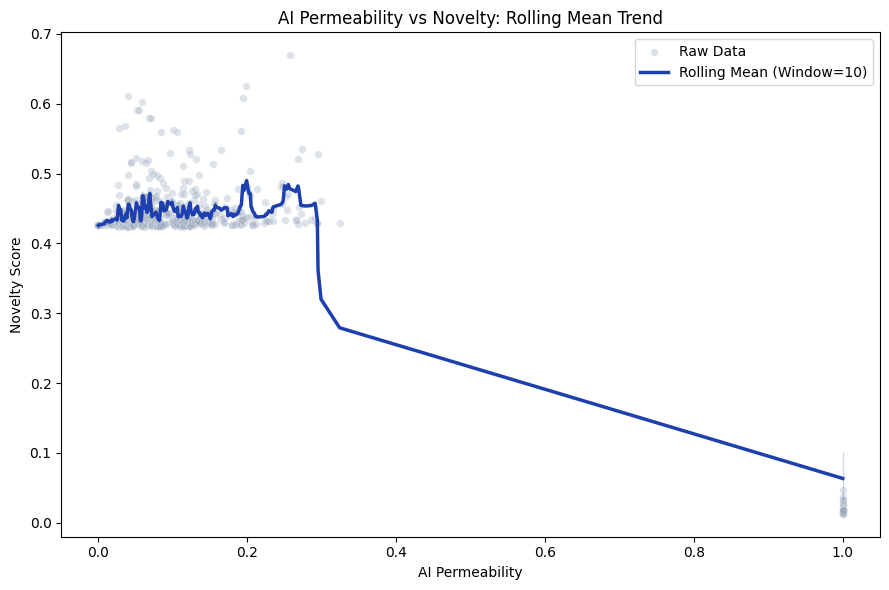

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据+排序+计算滚动均值
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty"]].dropna()
# 按AI渗透率升序排序
df_sorted = df.sort_values("ai_permeability").reset_index(drop=True)
# 计算滚动均值（窗口=10，每10个样本取均值，平滑趋势）
df_sorted["novelty_rolling_mean"] = df_sorted["Novelty"].rolling(window=10, center=True).mean()

# 2. 画滚动均值图
plt.figure(figsize=(9, 6))

# 原始散点（浅灰色，弱化个体）
sns.scatterplot(
    data=df_sorted,
    x="ai_permeability",
    y="Novelty",
    color="#94A3B8",
    alpha=0.3,
    s=30,
    label="Raw Data"
)

# 滚动均值折线（深色，突出趋势）
sns.lineplot(
    data=df_sorted.dropna(subset=["novelty_rolling_mean"]),  # 去掉窗口边缘的NaN
    x="ai_permeability",
    y="novelty_rolling_mean",
    color="#1E40AF",
    linewidth=2.5,
    label="Rolling Mean (Window=10)"
)

# 标签（仅核心变量）
plt.title("AI Permeability vs Novelty: Rolling Mean Trend")
plt.xlabel("AI Permeability")
plt.ylabel("Novelty Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

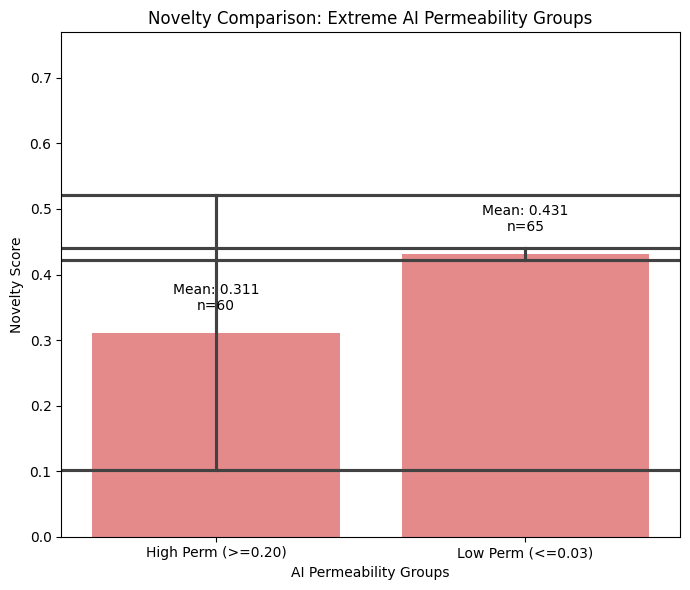

Novelty Statistics (Extreme Groups):
                     mean    std  count
perm_extreme                           
High Perm (>=0.20)  0.311  0.210     60
Low Perm (<=0.03)   0.431  0.009     65


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据+筛选极端区间
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty"]].dropna()
# 计算AI渗透率10%和90%分位数
perm_10 = df["ai_permeability"].quantile(0.1)
perm_90 = df["ai_permeability"].quantile(0.9)
# 筛选低渗透（<10%分位数）和高渗透（>90%分位数）样本
df_extreme = df[(df["ai_permeability"] <= perm_10) | (df["ai_permeability"] >= perm_90)].copy()
# 标记区间
df_extreme["perm_extreme"] = df_extreme["ai_permeability"].apply(
    lambda x: f"Low Perm (<={perm_10:.2f})" if x <= perm_10 
    else f"High Perm (>={perm_90:.2f})"
)

# 2. 画极端区间对比图
plt.figure(figsize=(7, 6))
# 柱状图（均值+标准差）
sns.barplot(
    data=df_extreme,
    x="perm_extreme",
    y="Novelty",
    color="#EF4444",
    alpha=0.7,
    errorbar="sd",  # 误差线=标准差
    capsize=8
)

# 标注均值和样本量
for i, (group, data) in enumerate(df_extreme.groupby("perm_extreme")):
    mean_novelty = data["Novelty"].mean()
    count = len(data)
    plt.text(
        i,
        mean_novelty + 0.03,
        f"Mean: {mean_novelty:.3f}\nn={count}",
        ha="center", va="bottom",
        fontsize=10
    )

# 标签（仅核心变量）
plt.title("Novelty Comparison: Extreme AI Permeability Groups")
plt.xlabel("AI Permeability Groups")
plt.ylabel("Novelty Score")
plt.ylim(0, df_extreme["Novelty"].max() + 0.1)
plt.tight_layout()
plt.show()

# 打印极端区间统计
print("Novelty Statistics (Extreme Groups):")
print(df_extreme.groupby("perm_extreme")["Novelty"].agg(["mean", "std", "count"]).round(3))

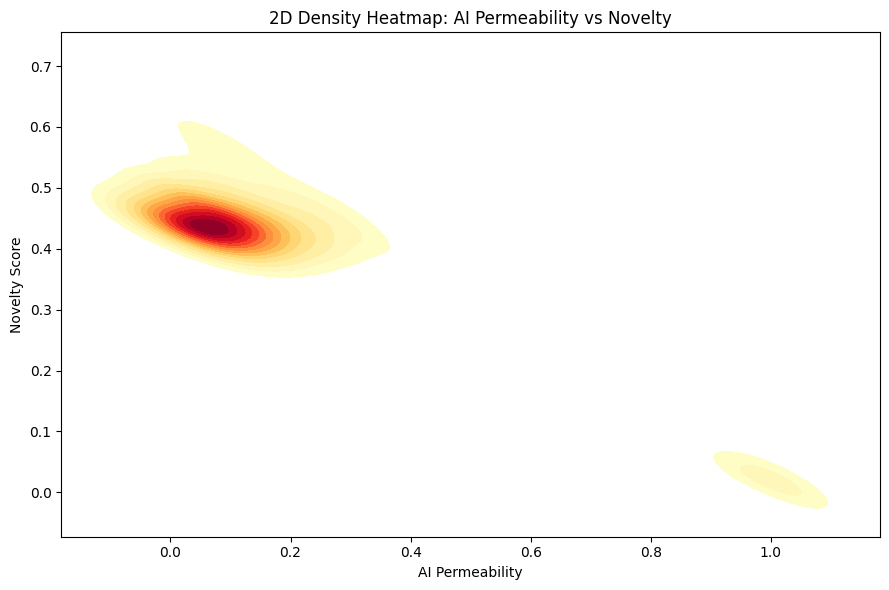

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据（仅核心两列）
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty"]].dropna()

# 2. 画二维密度热力图
plt.figure(figsize=(9, 6))
sns.kdeplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    fill=True,  # 填充颜色（密度越高颜色越深）
    cmap="YlOrRd",  # 黄色=低密度，红色=高密度
    levels=15,  # 密度层级（越高越精细）
    cbar_kws={"label": "Data Density"}  # 颜色条标签
)

# 标签（仅核心变量）
plt.title("2D Density Heatmap: AI Permeability vs Novelty")
plt.xlabel("AI Permeability")
plt.ylabel("Novelty Score")
plt.tight_layout()
plt.show()

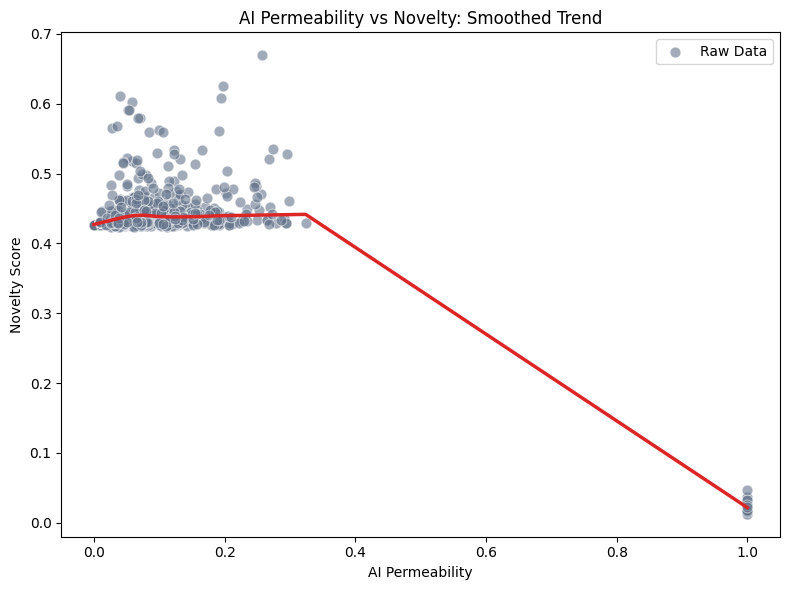

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据（仅保留核心两列，避免干扰）
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty"]].dropna()

# 2. 画平滑拟合图（聚焦AI渗透率×创新性）
plt.figure(figsize=(8, 6))

# 散点图（原始数据分布）
sns.scatterplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    color="#64748B",
    alpha=0.6,
    s=60,
    label="Raw Data"
)

# LOESS平滑拟合（更真实的趋势线）
sns.regplot(
    data=df,
    x="ai_permeability",
    y="Novelty",
    lowess=True,  # 关键：非参数平滑拟合
    color="#DC2626",
    line_kws={"linewidth": 2.5, "label": "LOESS Smoothed Trend"},
    scatter=False
)

# 标签（仅核心变量）
plt.title("AI Permeability vs Novelty: Smoothed Trend")
plt.xlabel("AI Permeability")
plt.ylabel("Novelty Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

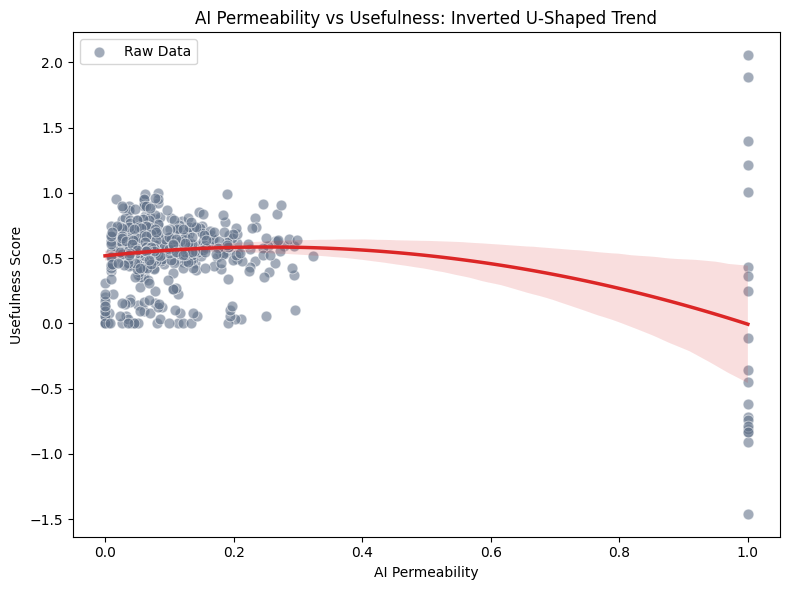

Quadratic Fit R²: 0.1244


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据（仅保留核心两列，删除缺失值）
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Usefulness"]].dropna()

# 2. 画二次拟合图（带95%置信区间）
plt.figure(figsize=(8, 6))

# 散点图（原始数据分布）
sns.scatterplot(
    data=df,
    x="ai_permeability",
    y="Usefulness",
    color="#64748B",
    alpha=0.6,
    s=60,
    label="Raw Data"
)

# 二次拟合（倒U型核心趋势，带置信区间）
sns.regplot(
    data=df,
    x="ai_permeability",
    y="Usefulness",
    order=2,  # 二次拟合=倒U型
    color="#DC2626",
    scatter=False,
    line_kws={"linewidth": 2.5, "label": "Quadratic Fit (Inverted U)"},
    ci=95  # 95%置信区间（阴影部分）
)

# 标签（仅核心变量）
plt.title("AI Permeability vs Usefulness: Inverted U-Shaped Trend")
plt.xlabel("AI Permeability")
plt.ylabel("Usefulness Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 计算拟合优度R²（论文量化引用）
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df["ai_perm_sq"] = df["ai_permeability"] ** 2
X = df[["ai_permeability", "ai_perm_sq"]]
y = df["Usefulness"]
r2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
print(f"Quadratic Fit R²: {r2:.4f}")

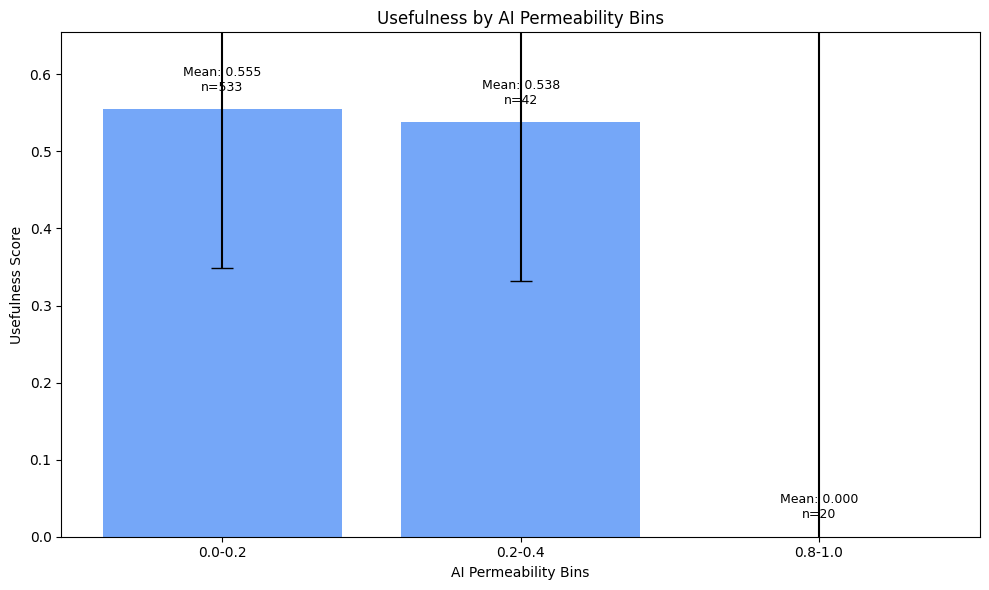

Usefulness Statistics by AI Permeability Bins:
  ai_perm_bin   mean    std  count
0     0.0-0.2  0.555  0.206    533
1     0.2-0.4  0.538  0.206     42
2     0.8-1.0  0.000  1.026     20


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据+拆分AI渗透率区间
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Usefulness"]].dropna()
# 拆分为5个等宽区间（覆盖0-1全范围）
df["ai_perm_bin"] = pd.cut(
    df["ai_permeability"],
    bins=5,
    labels=["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"],
    include_lowest=True
)

# 2. 计算每个区间的实用性统计（均值+标准差+样本量）
usefulness_stats = df.groupby("ai_perm_bin")["Usefulness"].agg(["mean", "std", "count"]).reset_index()

# 3. 画区间-实用性对比图
plt.figure(figsize=(10, 6))
bars = plt.bar(
    x=usefulness_stats["ai_perm_bin"],
    height=usefulness_stats["mean"],
    yerr=usefulness_stats["std"],  # 误差线=标准差（展示波动）
    capsize=8,
    color="#3B82F6",
    alpha=0.7
)

# 标注：每个柱子上方加“均值+样本量”（增强可信度）
for i, bar in enumerate(bars):
    mean_val = usefulness_stats["mean"].iloc[i]
    count_val = usefulness_stats["count"].iloc[i]
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        mean_val + 0.02,
        f"Mean: {mean_val:.3f}\nn={count_val}",
        ha="center", va="bottom",
        fontsize=9
    )

# 标签（仅核心变量）
plt.title("Usefulness by AI Permeability Bins")
plt.xlabel("AI Permeability Bins")
plt.ylabel("Usefulness Score")
plt.ylim(0, usefulness_stats["mean"].max() + 0.1)  # 预留标签空间
plt.tight_layout()
plt.show()

# 打印详细统计（论文直接引用）
print("Usefulness Statistics by AI Permeability Bins:")
print(usefulness_stats.round(3))

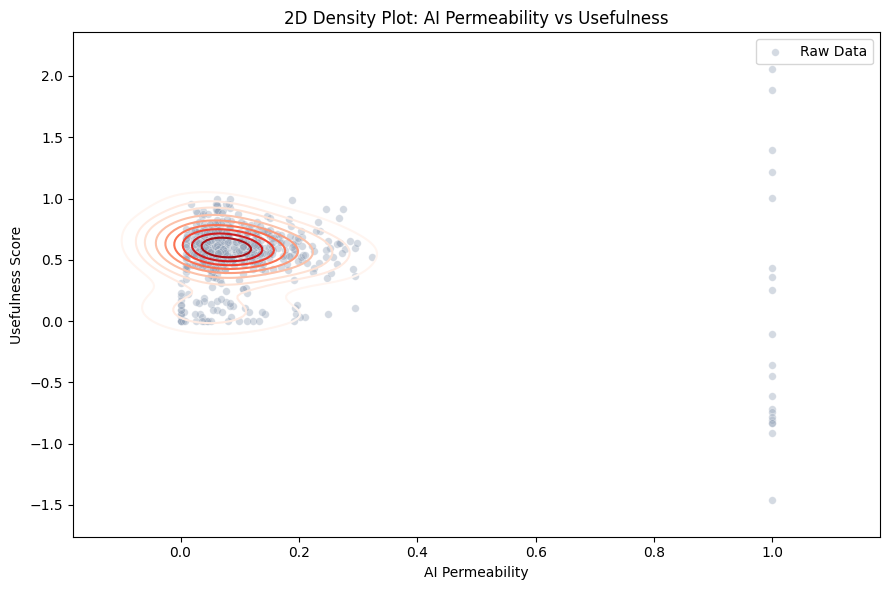

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据（仅核心两列）
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Usefulness"]].dropna()

# 2. 画二维密度散点图（颜色=密度）
plt.figure(figsize=(9, 6))
sns.kdeplot(
    data=df,
    x="ai_permeability",
    y="Usefulness",
    cmap="Reds",  # 红色系：密度越高颜色越深
    fill=False,  # 不填充，用散点密度表示
    thresh=0.1,  # 只显示密度>0.1的区域（过滤稀疏点）
    levels=10,   # 密度层级（越高越精细）
)

# 叠加原始散点（浅灰色，突出密度区域）
sns.scatterplot(
    data=df,
    x="ai_permeability",
    y="Usefulness",
    color="#94A3B8",
    alpha=0.4,
    s=30,
    label="Raw Data"
)

# 标签（仅核心变量）
plt.title("2D Density Plot: AI Permeability vs Usefulness")
plt.xlabel("AI Permeability")
plt.ylabel("Usefulness Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

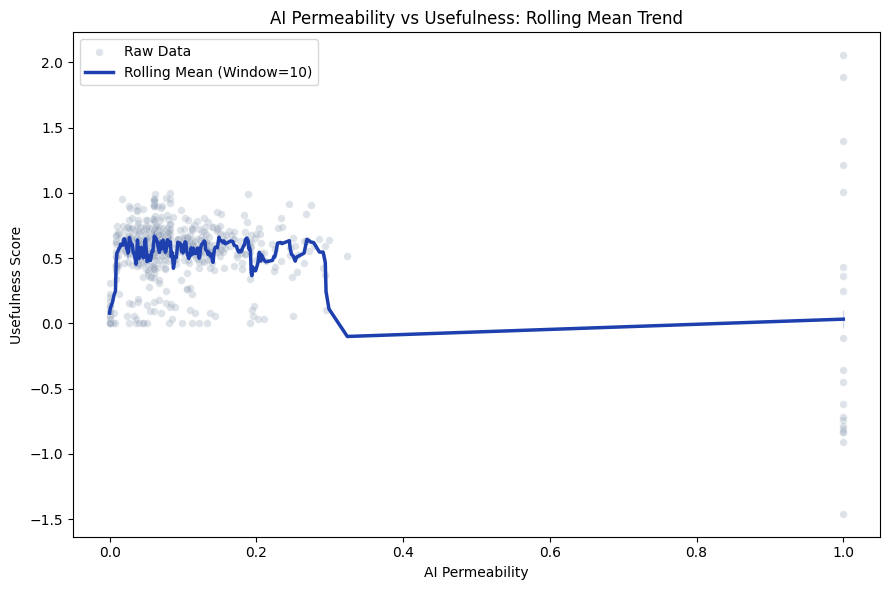

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取数据+排序+计算滚动均值
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Usefulness"]].dropna()
# 按AI渗透率升序排序（确保趋势连贯）
df_sorted = df.sort_values("ai_permeability").reset_index(drop=True)
# 滚动均值（窗口=10，中心对齐，平滑趋势）
df_sorted["usefulness_rolling_mean"] = df_sorted["Usefulness"].rolling(window=10, center=True).mean()

# 2. 画滚动均值趋势图
plt.figure(figsize=(9, 6))

# 原始散点（浅灰色，弱化个体，突出趋势）
sns.scatterplot(
    data=df_sorted,
    x="ai_permeability",
    y="Usefulness",
    color="#94A3B8",
    alpha=0.3,
    s=30,
    label="Raw Data"
)

# 滚动均值折线（深蓝色，突出核心趋势）
sns.lineplot(
    data=df_sorted.dropna(subset=["usefulness_rolling_mean"]),  # 删除窗口边缘的NaN
    x="ai_permeability",
    y="usefulness_rolling_mean",
    color="#1E40AF",
    linewidth=2.5,
    label="Rolling Mean (Window=10)"
)

# 标签（仅核心变量）
plt.title("AI Permeability vs Usefulness: Rolling Mean Trend")
plt.xlabel("AI Permeability")
plt.ylabel("Usefulness Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty", "Usefulness"]].dropna()
df["ai_perm_sq"] = df["ai_permeability"] ** 2

# 1. Novelty 二次回归
X_nov = sm.add_constant(df[["ai_permeability", "ai_perm_sq"]])
model_nov = sm.OLS(df["Novelty"], X_nov).fit()
print("=== Quadratic Regression: AI Permeability × Novelty ===")
print(model_nov.summary().tables[1])
print(f"R²: {model_nov.rsquared:.4f}\n")

# 2. Usefulness 二次回归
X_use = sm.add_constant(df[["ai_permeability", "ai_perm_sq"]])
model_use = sm.OLS(df["Usefulness"], X_use).fit()
print("=== Quadratic Regression: AI Permeability × Usefulness ===")
print(model_use.summary().tables[1])
print(f"R²: {model_use.rsquared:.4f}")

=== Quadratic Regression: AI Permeability × Novelty ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4337      0.002    178.021      0.000       0.429       0.439
ai_permeability     0.2372      0.026      8.989      0.000       0.185       0.289
ai_perm_sq         -0.6489      0.026    -25.038      0.000      -0.700      -0.598
R²: 0.8606

=== Quadratic Regression: AI Permeability × Usefulness ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.5183      0.021     24.212      0.000       0.476       0.560
ai_permeability     0.5346      0.232      2.306      0.021       0.079       0.990
ai_perm_sq         -1.0591      0.228     -4.651      0.000      -1.506      -0.612
R²: 0.1244


In [26]:
# 导入需要的库
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score

# 1. 读取数据 + 筛选低渗透率组（核心：仅保留0 ≤ ai_permeability ≤ 0.3的样本）
df = pd.read_csv("merged_novelty_usefulness_results.csv")[["ai_permeability", "Novelty", "Usefulness"]].dropna()
# 筛选低渗透率组（实验组）
df_low_perm = df[(df["ai_permeability"] >= 0) & (df["ai_permeability"] <= 0.3)].copy()

# 2. 准备二次项（用于检验低渗透区间内是否存在非线性趋势）
df_low_perm["ai_perm_sq"] = df_low_perm["ai_permeability"] ** 2

# --------------------------
# 模型1：低渗透率组 - AI渗透率 × 创新性（Novelty）线性回归
# 目的：检验低渗透区间内，AI渗透率是否对创新性有显著线性影响
# --------------------------
print("="*60)
print("Model 1: Low Permeability Group (0-0.3) - Linear Regression (AI Permeability → Novelty)")
print("="*60)
# 自变量：AI渗透率（一次项），加常数项
X_nov_linear = sm.add_constant(df_low_perm[["ai_permeability"]])
y_nov = df_low_perm["Novelty"]
# 拟合模型
model_nov_linear = sm.OLS(y_nov, X_nov_linear).fit()
# 输出关键结果
print(model_nov_linear.summary().tables[1])  # 系数表（含p值）
print(f"R² (Model Fit): {r2_score(y_nov, model_nov_linear.predict(X_nov_linear)):.4f}")
print(f"Sample Size (n): {len(df_low_perm)}")
print()  # 空行分隔

# --------------------------
# 模型2：低渗透率组 - AI渗透率 × 创新性（Novelty）二次回归
# 目的：检验低渗透区间内，是否存在“先升后稳”等非线性趋势
# --------------------------
print("="*60)
print("Model 2: Low Permeability Group (0-0.3) - Quadratic Regression (AI Permeability → Novelty)")
print("="*60)
# 自变量：AI渗透率（一次项+二次项），加常数项
X_nov_quad = sm.add_constant(df_low_perm[["ai_permeability", "ai_perm_sq"]])
# 拟合模型
model_nov_quad = sm.OLS(y_nov, X_nov_quad).fit()
# 输出关键结果
print(model_nov_quad.summary().tables[1])
print(f"R² (Model Fit): {r2_score(y_nov, model_nov_quad.predict(X_nov_quad)):.4f}")
print(f"Sample Size (n): {len(df_low_perm)}")
# 计算低渗透区间内的潜在临界点（若二次项显著）
if abs(model_nov_quad.params["ai_perm_sq"]) > 1e-8:  # 避免除以0
    critical_point_nov = -model_nov_quad.params["ai_permeability"] / (2 * model_nov_quad.params["ai_perm_sq"])
    print(f"Potential Critical Point (Max Novelty in 0-0.3): {critical_point_nov:.4f}")
print()

# --------------------------
# 模型3：低渗透率组 - AI渗透率 × 实用性（Usefulness）线性回归
# 目的：检验低渗透区间内，AI渗透率是否对实用性有显著线性影响
# --------------------------
print("="*60)
print("Model 3: Low Permeability Group (0-0.3) - Linear Regression (AI Permeability → Usefulness)")
print("="*60)
# 自变量：AI渗透率（一次项），加常数项
X_use_linear = sm.add_constant(df_low_perm[["ai_permeability"]])
y_use = df_low_perm["Usefulness"]
# 拟合模型
model_use_linear = sm.OLS(y_use, X_use_linear).fit()
# 输出关键结果
print(model_use_linear.summary().tables[1])
print(f"R² (Model Fit): {r2_score(y_use, model_use_linear.predict(X_use_linear)):.4f}")
print(f"Sample Size (n): {len(df_low_perm)}")
print()

# --------------------------
# 模型4：低渗透率组 - AI渗透率 × 实用性（Usefulness）二次回归
# 目的：检验低渗透区间内，是否存在“先升后稳”等非线性趋势
# --------------------------
print("="*60)
print("Model 4: Low Permeability Group (0-0.3) - Quadratic Regression (AI Permeability → Usefulness)")
print("="*60)
# 自变量：AI渗透率（一次项+二次项），加常数项
X_use_quad = sm.add_constant(df_low_perm[["ai_permeability", "ai_perm_sq"]])
# 拟合模型
model_use_quad = sm.OLS(y_use, X_use_quad).fit()
# 输出关键结果
print(model_use_quad.summary().tables[1])
print(f"R² (Model Fit): {r2_score(y_use, model_use_quad.predict(X_use_quad)):.4f}")
print(f"Sample Size (n): {len(df_low_perm)}")
# 计算低渗透区间内的潜在临界点（若二次项显著）
if abs(model_use_quad.params["ai_perm_sq"]) > 1e-8:
    critical_point_use = -model_use_quad.params["ai_permeability"] / (2 * model_use_quad.params["ai_perm_sq"])
    print(f"Potential Critical Point (Max Usefulness in 0-0.3): {critical_point_use:.4f}")
print("="*60)

Model 1: Low Permeability Group (0-0.3) - Linear Regression (AI Permeability → Novelty)
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4401      0.002    193.350      0.000       0.436       0.445
ai_permeability     0.0792      0.021      3.817      0.000       0.038       0.120
R² (Model Fit): 0.0248
Sample Size (n): 574

Model 2: Low Permeability Group (0-0.3) - Quadratic Regression (AI Permeability → Novelty)
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4382      0.003    125.377      0.000       0.431       0.445
ai_permeability     0.1259      0.067      1.883      0.060      -0.005       0.257
ai_perm_sq         -0.1860      0.253     -0.735      0.463      -0.683       0.311
R² (Model Fit): 0.02

/var/folders/p6/8w2v2cgx5zjflr0zwpfp9fvh0000gn/T/ipykernel_79203/228847898.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


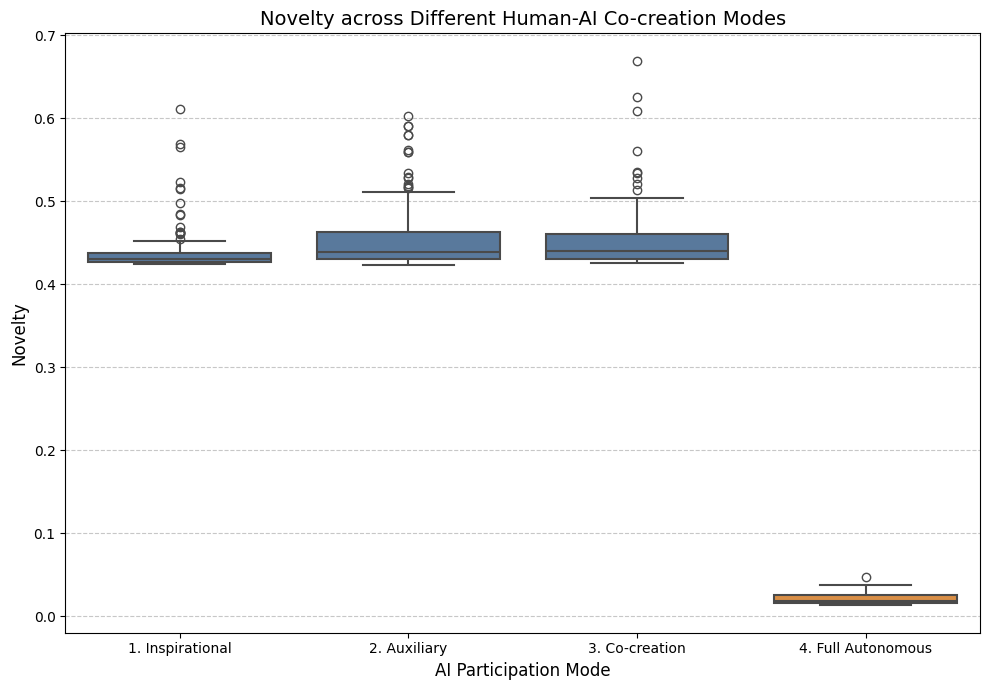

=== Novelty Statistics by AI Participation Mode ===
                     mean  count
ai_mode                         
1. Inspirational    0.438    164
2. Auxiliary        0.449    322
3. Co-creation      0.456     89
4. Full Autonomous  0.022     20


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据，标记作品类型
df = pd.read_csv("merged_novelty_usefulness_results.csv")

# 按AI渗透率标记模式
def categorize_mode(perm):
    if perm == 1.0:
        return "4. Full Autonomous"
    elif perm <= 0.05:
        return "1. Inspirational"
    elif perm <= 0.15:
        return "2. Auxiliary"
    else:
        return "3. Co-creation"

df["ai_mode"] = df["ai_permeability"].apply(categorize_mode)

# 强制设置顺序
mode_order = ["1. Inspirational", "2. Auxiliary", "3. Co-creation", "4. Full Autonomous"]
# 第四组用橙色突出
palette = ["#4E79A7", "#4E79A7", "#4E79A7", "#F28E2C"]

# 2. 绘制箱线图
plt.figure(figsize=(10, 7))
sns.boxplot(
    data=df,
    x="ai_mode",
    y="Novelty",
    order=mode_order,
    palette=palette,
    linewidth=1.5
)

# 添加标题和标签
plt.title("Novelty across Different Human-AI Co-creation Modes", fontsize=14)
plt.xlabel("AI Participation Mode", fontsize=12)
plt.ylabel("Novelty", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 打印统计结果
print("=== Novelty Statistics by AI Participation Mode ===")
print(df.groupby("ai_mode")["Novelty"].agg(["mean", "count"]).round(3).reindex(mode_order))